### Importancia de la Normalización de las características para el algoritmo K-Neighbors

En este ejercicio vamos a ver que es crítico el uso de componentes normalizadas en conjuntos de datos donde los rangos de valores son muy diferentes entre características. 

Consideremos la tabla 'ventas.csv' que indica si hemos conseguido vender un seguro de vida a diferentes potenciales clientes de los cuales sabemos su sueldo y su edad. 

La idea es hacer un predictor al que introduciéndole el sueldo y la edad del potencial cliente nos indique si es probable que nos compre el seguro de vida. Para ello vamos a utilizar el algoritmo de los K-vecinos. Específicamente vamos a buscar el vecino más próximo al dato de consulta y asumiremos que el comportamiento previsto será el de dicho vecino.

In [2]:
#cargamos el dataset de los clientes que conocemos en un DataFrame.Llámalo 'data'

import pandas as pd
import numpy as np

#Código aquí.Usa el método de Pandas para leer archivos csv. El separador aquí es el símbolo ';'
data = pd.read_csv('ventas.csv', sep=';')
print(data)



   Sueldo  Edad Compra
0   53700    41     no
1   65300    37     no
2   48900    45     si
3   64800    49     si
4   44200    30     no
5   55900    57     si
6   48600    26     no
7   72800    60     si
8   45300    34     no
9   73200    52     si


In [9]:
#Del original separamos las columnnas que harán de puntos en un espacio 2D 'Sueldo' y 'Edad'  
#y dejamos en otro dataframe la columna 'Compra' que es la respuesta a la consulta

gt = data.drop(['Sueldo', 'Edad' ], axis=1)
Y = data.drop(['Compra'], axis=1)

#Las transformamos en arrays
Ynp = Y.to_numpy()

gtnp = gt.to_numpy()  

In [10]:
#cargamos el algoritmo de K-Neighbors
from sklearn.neighbors import KNeighborsClassifier

#preparamos el clasificador para devolver el primer vecino mas próximo. Lo llamamos 'neigh'

#Código aquí
neigh = KNeighborsClassifier(n_neighbors=1)  # Solo el vecino más cercano

#Introducimos el dataset para que realice el aprendizaje
neigh.fit(Ynp, np.ravel(gtnp))
print("✓ Modelo KNN entrenado correctamente")
print(f"Usando {Ynp.shape[0]} muestras y {Ynp.shape[1]} características")

✓ Modelo KNN entrenado correctamente
Usando 10 muestras y 2 características


In [16]:
!pip install category_encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 994.0 kB/s eta 0:00:00 kB/s eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.9/232.9 kB 887.6 kB/s eta 0:00:00 kB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 1.2 MB/s eta 0:00:00m eta 0:00:010:00:010m

[notice] A new release of pip is available: 24.0 -> 25.2
[notice] To update, run: pip install --upgrade pip


# Codificación binaria de caracter 
Como sabemos, a los datos con características categóricas no se les puede aplicar directamente una métrica (como la euclídea)
Vamos a codificar de manera binaria los valores 'si' 'no' de la tabla de respuestas 'Compra' para utilizarlos como índice en el array 'marker'. 
Así los que no compran se visualizarán como puntos en forma de aspa y los que compran se visualizarán como triángulos.

In [17]:
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8-whitegrid')

#Definimos los símbolos que representamos en el diagrama
marker=['x','^']

import category_encoders as ce
encoder = ce.BinaryEncoder()

#Pon aquí la instrucción que codifica usando el encoder los datos no numéricos del array 'gtnp'. Llámalo 'gtnpq'
gtnpq = encoder.fit_transform(gtnp)

print("=== CODIFICACIÓN BINARIA ===")
print("Datos ORIGINALES (gtnp):")
print(gtnp)
print("\nDatos CODIFICADOS (gtnpq):")
print(gtnpq)
print(f"Tipo de gtnpq: {type(gtnpq)}")

pp=np.array(gtnpq)

print(f"\nArray pp (para los marcadores):")
print(pp)
print(f"Dimensiones de pp: {pp.shape}")

=== CODIFICACIÓN BINARIA ===
Datos ORIGINALES (gtnp):
[['no']
 ['no']
 ['si']
 ['si']
 ['no']
 ['si']
 ['no']
 ['si']
 ['no']
 ['si']]

Datos CODIFICADOS (gtnpq):
   0_0  0_1
0    0    1
1    0    1
2    1    0
3    1    0
4    0    1
5    1    0
6    0    1
7    1    0
8    0    1
9    1    0
Tipo de gtnpq: <class 'pandas.core.frame.DataFrame'>

Array pp (para los marcadores):
[[0 1]
 [0 1]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [1 0]]
Dimensiones de pp: (10, 2)


In [20]:
# Codificación binaria de caracter - VERSIÓN SIMPLIFICADA
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8-whitegrid')

# Definimos los símbolos
marker = ['x', '^']  # 'x' = no compra, '^' = sí compra

# Codificación MANUAL más simple
print("=== CODIFICACIÓN BINARIA ===")
print("Datos ORIGINALES (gtnp):")
print(gtnp)

# Convertimos a 0/1 manualmente
pp_simple = np.array([0 if compra[0] == 'no' else 1 for compra in gtnp])

print("\nDatos CODIFICADOS (pp_simple):")
print(pp_simple)
print(f"Dimensiones: {pp_simple.shape}")


=== CODIFICACIÓN BINARIA ===
Datos ORIGINALES (gtnp):
[['no']
 ['no']
 ['si']
 ['si']
 ['no']
 ['si']
 ['no']
 ['si']
 ['no']
 ['si']]

Datos CODIFICADOS (pp_simple):
[0 0 1 1 0 1 0 1 0 1]
Dimensiones: (10,)


#Visualizamos la gráfica

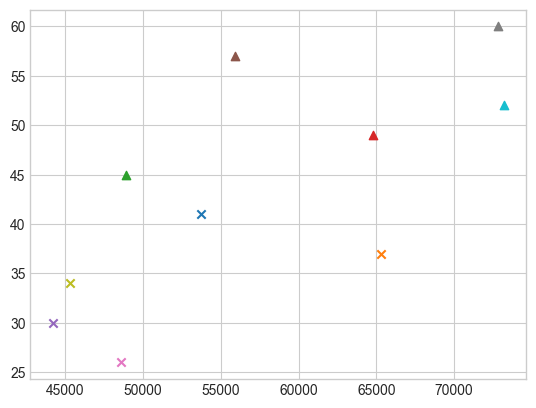

In [18]:
for i in range(0,10):
    plt.scatter(Ynp[i,0], Ynp[i,1], marker=marker[pp[i,0]])

**Pregunta 1**  Visualizando la gráfica podemos hacernos una idea de cuál es el perfil del cliente que NO va a comprar un seguro.
Especifica ese perfil. 


**Respuesta:**
Los clientes mayores de 45 años tienden a comprar el seguro, no obstante hay casos donde el sueldo influye, pero la edad parece ser mas determinante, como vemos en el caso del cliente de (41 años aproximadamente con un sueldo cerca de los 55.000€ superior al cliente de los 45 años, vemos como aun teniendo un sueldo superior no compra el seguro) También podemos observar como el cliente de 36/37 años aproximadamente tiene un salario bastante elevado pero tampoco compra seguro

Vamos a predecir si un cliente que cobra 56000 euros al año y tiene 35 años nos compraría el seguro o no. 
Para ello buscaremos el vecino más próximo y consultaremos la decisión que tomó ese vecino.

In [21]:
dist, index = neigh.kneighbors(np.array([56000 , 35]).reshape(1,-1),1,True)

print(dist)
print(index)

print("Vecino mas proximo")
print(data.iloc[index[0,0]])

[[102.39140589]]
[[5]]
Vecino mas proximo
Sueldo    55900
Edad         57
Compra       si
Name: 5, dtype: object


Vemos que el que nos ha dado como vecino más próximo, no parece cumplir el perfil del dato de consulta.
Si visualizamos el punto del potencial cliente buscado, no *'parece'* estar cercano al vecino más próximo en la gráfica:

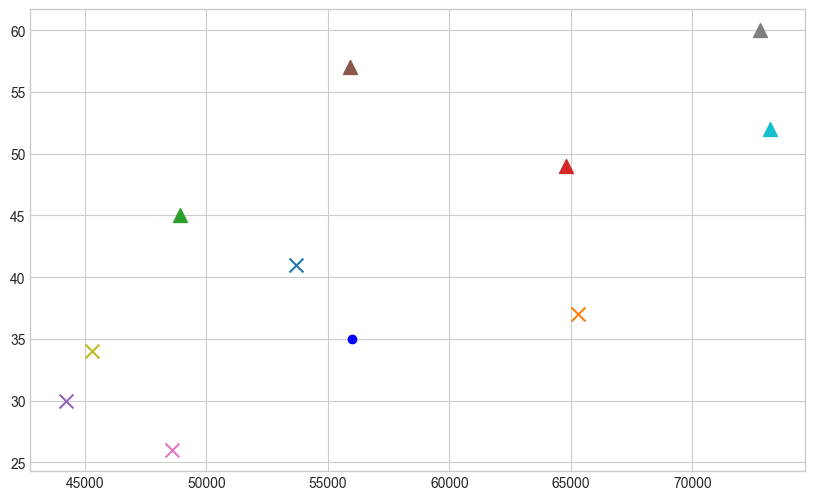

In [23]:
#Código aquí. Visualiza con plt.scatter el dataset Ynp utilizando 'marker' con la información de pp
plt.figure(figsize=(10, 6))

# Primero pintamos todos los clientes conocidos
for i in range(len(Ynp)):
    plt.scatter(Ynp[i,0], Ynp[i,1], marker=marker[pp_simple[i]], s=100, 
                label=f'Cliente {i}' if i < 3 else "")  # Etiquetamos solo los primeros 3

#pintamos el punto de query como un círculo de color azul
plt.scatter(56000,35,marker='o', color='blue')

**Pregunta** Explica con tus palabras a qué se debe este resultado.

**Respuesta:**
"El algoritmo considera que son cercanos porque tienen sueldos muy similares 
(solo 100€ de diferencia), pero visualmente están lejos porque tienen edades 
muy diferentes (22 años de diferencia). El sueldo domina el cálculo de la 
distancia porque usa números mucho más grandes que la edad."

Vamos a normalizar las características del array Ynp para que ambas se encuentren en el mismo rango. Para ello vamos a usar el método 
MinMaxScaler de sklearn.preprocessing
**Importante:** El método MinMaxScaler normaliza cada característica  *por separado* tomando como conjunto, dicha característica de todos los datos del Dataset. Hay otro tipo de normalización donde se normalizan las caracteristicas *de cada dato*, es decir, imponiendo que la norma euclídea (o módulo) de cada dato sea 1. Es decir, el módulo de un dato (vector) tras haber aplicado MinMaxScaler no tiene por qué dar 1.

In [24]:
from sklearn.preprocessing import MinMaxScaler

#Código aquí.
scaler = MinMaxScaler()

scaler.fit(Ynp)
Ynpnorm = scaler.transform(Ynp)

#observa ahora cómo los valores están normalizados
print("Datos normalizados:")
print(Ynpnorm)

#Llama ahora otra vez al clasificador de k-vecinos para un solo vecino
neigh2 = KNeighborsClassifier(n_neighbors=1)
neigh2.fit(Ynpnorm, np.ravel(gtnp))

#Obtén con scaler las características normalizadas del punto (56000,35)
query = scaler.transform([[56000, 35]])
print(f"\nPunto consulta normalizado: {query}")
#Obtén ahora con el clasificador neigh2 el vecino más próximo de query
dist2, index2 = neigh2.kneighbors(query, 1, True)

Datos normalizados:
[[0.32758621 0.44117647]
 [0.72758621 0.32352941]
 [0.16206897 0.55882353]
 [0.71034483 0.67647059]
 [0.         0.11764706]
 [0.40344828 0.91176471]
 [0.15172414 0.        ]
 [0.9862069  1.        ]
 [0.03793103 0.23529412]
 [1.         0.76470588]]

Punto consulta normalizado: [[0.40689655 0.26470588]]


In [25]:
#imprimimos el nuevo resultado
print("Vecino mas proximo")
print(data.iloc[index2[0,0]])


Vecino mas proximo
Sueldo    53700
Edad         41
Compra       no
Name: 0, dtype: object


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


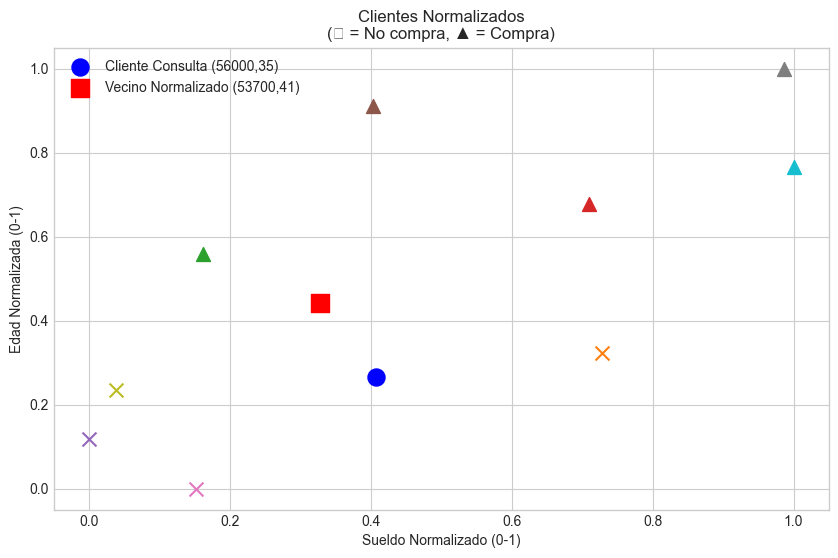

In [26]:
#Código aquí. Visualiza con plt.scatter el dataset normalizado
# Código aquí. Visualiza con plt.scatter el dataset normalizado
plt.figure(figsize=(10, 6))

# Pintamos todos los clientes normalizados
for i in range(len(Ynpnorm)):
    plt.scatter(Ynpnorm[i,0], Ynpnorm[i,1], marker=marker[pp_simple[i]], s=100)

# Pintamos el punto de query normalizado
plt.scatter(query[0,0], query[0,1], marker='o', color='blue', s=150, 
           label='Cliente Consulta (56000,35)')

# Pintamos el NUEVO vecino más cercano (normalizado)
vecino_norm = data.iloc[0]  # El cliente 0 que encontró
plt.scatter(Ynpnorm[0,0], Ynpnorm[0,1], marker='s', color='red', s=150, 
           label='Vecino Normalizado (53700,41)')

plt.xlabel('Sueldo Normalizado (0-1)')
plt.ylabel('Edad Normalizada (0-1)')
plt.title('Clientes Normalizados\n(❌ = No compra, ▲ = Compra)')
plt.grid(True)
plt.legend()
plt.show()

Observa la gráfica y explica el resultado que has obtenido con el nuevo dato normalizado 'query'.

**Respuesta:**
"Con la normalización, el algoritmo ahora encuentra un vecino que visualmente 
sí está cerca del punto de consulta. Ambos tienen edades y sueldos similares, 
y la predicción (NO comprará) es coherente con el perfil de clientes jóvenes 
con sueldos medios que hemos observado en los datos."

In [27]:
**Recuerda: ** 
Si en los datos todas las características tienen el mismo peso, deben estar en rangos de valores parecidos al emplear la métrica euclídea (y otras). Eso se consigue con la **normalización** de los datos.

SyntaxError: invalid syntax (3356191231.py, line 1)